In [6]:
import pandas as pd

df = pd.read_csv('outputs/rookie_roi.csv')

df.head()



,Unnamed: 0,season,round,pick,team_x,gsis_id_x,pfr_player_id,cfb_player_id,pfr_player_name,hof,...,player_page,gsis_id,date_of_birth,college_y,draft_year_y,draft_round_y,draft_overall,draft_team_y,cols,roi_ratio
0,773879,1998,1,21,MIN,00-0011754,MossRa00,randy-moss-1,Randy Moss,True,...,https://overthecap.com/player/randy-moss/86/,00-0011754,NaN,Marshall,1998.0,1.0,21.0,Vikings,"[{'year': '1998', 'team': 'Vikings', 'base_sal...",5636.363636
1,828027,2001,2,32,SDG,00-0020531,BreeDr00,drew-brees-1,Drew Brees,True,...,https://overthecap.com/player/drew-brees/1492/,00-0020531,"January 15, 1979",Purdue,2001.0,2.0,32.0,Chargers,"[{'year': '2001', 'team': 'Chargers', 'base_sa...",12846.153846
2,859527,2003,2,35,CHI,00-0022123,TillCh20,charles-tillman-1,Charles Tillman,False,...,https://overthecap.com/player/charles-tillman/...,00-0022123,"February 23, 1981",Louisiana-Lafayette,2003.0,2.0,35.0,Bears,"[{'year': '2003', 'team': 'Bears', 'base_salar...",6000.000000
3,859542,2003,2,54,ARI,00-0022084,BoldAn00,anquan-boldin-1,Anquan Boldin,False,...,https://overthecap.com/player/anquan-boldin/1360/,00-0022084,"October 3, 1980",Florida State,2003.0,2.0,54.0,Cardinals,"[{'year': '2003', 'team': 'Cardinals', 'base_s...",9555.555556
4,859546,2003,2,56,NYG,00-0021977,UmenOs99,NaN,Osi Umenyiora,False,...,https://overthecap.com/player/osi-umenyiora/138/,00-0021977,"November 16, 1981",Troy,2003.0,2.0,56.0,Giants,"[{'year': '2003', 'team': 'Giants', 'base_sala...",7875.000000


In [7]:
df.info(verbose=True)
df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 3822 entries, 0 to 3821
Data columns (total 99 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    3822 non-null   int64  
 1   season                        3822 non-null   int64  
 2   round                         3822 non-null   int64  
 3   pick                          3822 non-null   int64  
 4   team_x                        3822 non-null   str    
 5   gsis_id_x                     3822 non-null   str    
 6   pfr_player_id                 3822 non-null   str    
 7   cfb_player_id                 3478 non-null   str    
 8   pfr_player_name               3822 non-null   str    
 9   hof                           3822 non-null   bool   
 10  position                      3822 non-null   str    
 11  category                      3822 non-null   str    
 12  side                          3820 non-null   str    
 13  college_x     

Unnamed: 0         int64
season             int64
round              int64
pick               int64
team_x               str
                  ...   
draft_round_y    float64
draft_overall    float64
draft_team_y         str
cols                 str
roi_ratio        float64
Length: 99, dtype: object

In [8]:
print(df[['games', 'pass_completions', 'pass_attempts', 'pass_yards', 'pass_tds', 'pass_ints', 'rush_atts', 'rush_yards', 'rush_tds', 'receptions', 'rec_yards', 'rec_tds', 'def_solo_tackles', 'def_ints', 'def_sacks']].dtypes)

games               float64
pass_completions    float64
pass_attempts       float64
pass_yards          float64
pass_tds            float64
pass_ints           float64
rush_atts           float64
rush_yards          float64
rush_tds            float64
receptions          float64
rec_yards           float64
rec_tds             float64
def_solo_tackles    float64
def_ints            float64
def_sacks           float64
dtype: object


In [9]:
player_df = pd.read_csv('player.csv')
player_df.columns

Index(['Player Code', 'Team Code', 'Last Name', 'First Name', 'Uniform Number',
       'Class', 'Position', 'Height', 'Weight', 'Home Town', 'Home State',
       'Home Country', 'Last School'],
      dtype='str')

In [10]:
player_df['full_name'] = player_df['First Name'] + ' ' + player_df['Last Name']
player_df['full_name'].head()

0        Andy Alleman
1          Alex Allen
2    Michael Alphonse
3    Brandon Anderson
4       Zack Anderson
Name: full_name, dtype: str

In [11]:
print(player_df.shape)
player_df.head()

(22879, 14)


,Player Code,Team Code,Last Name,First Name,Uniform Number,Class,Position,Height,Weight,Home Town,Home State,Home Country,Last School,full_name
0,85454,5,Alleman,Andy,57,JR,OL,NaN,NaN,NaN,NaN,NaN,NaN,Andy Alleman
1,85455,5,Allen,Alex,3A,FR,RB,NaN,NaN,NaN,NaN,NaN,NaN,Alex Allen
2,85456,5,Alphonse,Michael,52,FR,LB,NaN,NaN,NaN,NaN,NaN,NaN,Michael Alphonse
3,85457,5,Anderson,Brandon,28,FR,DB,NaN,NaN,NaN,NaN,NaN,NaN,Brandon Anderson
4,85458,5,Anderson,Zack,78,FR,OL,NaN,NaN,NaN,NaN,NaN,NaN,Zack Anderson


In [12]:
shared = pd.merge(left=df, right=player_df, left_on='pfr_player_name', right_on='full_name',how='inner')
shared.head()

,Unnamed: 0,season,round,pick,team_x,gsis_id_x,pfr_player_id,cfb_player_id,pfr_player_name,hof,...,Uniform Number,Class,Position,Height,Weight,Home Town,Home State,Home Country,Last School,full_name
0,906558,2006,1,3,TEN,00-0024218,YounVi00,vince-young-1,Vince Young,False,...,10,JR,QB,NaN,NaN,NaN,NaN,NaN,NaN,Vince Young
1,906661,2006,2,33,HOU,00-0024248,RyanDe20,demeco-ryans-1,DeMeco Ryans,False,...,35,SR,LB,NaN,NaN,NaN,NaN,NaN,NaN,DeMeco Ryans
2,906666,2006,2,34,CLE,00-0024249,JackDQ20,dqwell-jackson-1,D'Qwell Jackson,False,...,52,SR,LB,NaN,NaN,NaN,NaN,NaN,NaN,D'Qwell Jackson
3,906683,2006,2,43,NOR,00-0024258,HarpRo21,roman-harper-1,Roman Harper,False,...,41,SR,DB,NaN,NaN,NaN,NaN,NaN,NaN,Roman Harper
4,906688,2006,2,47,GNB,00-0024262,CollDa20,NaN,Daryn Colledge,False,...,73,SR,OL,NaN,NaN,NaN,NaN,NaN,NaN,Daryn Colledge


In [13]:

shared[['Player Code', 'full_name', 'pfr_player_name']].head(20)

,Player Code,full_name,pfr_player_name
0,65982,Vince Young,Vince Young
1,65904,DeMeco Ryans,DeMeco Ryans
2,49038,D'Qwell Jackson,D'Qwell Jackson
3,45348,Roman Harper,Roman Harper
4,61189,Daryn Colledge,Daryn Colledge
5,41759,Greg Jennings,Greg Jennings
6,50206,Anthony Fasano,Anthony Fasano
7,58470,Bernard Pollard,Bernard Pollard
8,48804,Andrew Whitworth,Andrew Whitworth
9,37718,Chris Chester,Chris Chester


In [14]:
shared.shape

(481, 113)

In [15]:
other_complete = pd.read_csv('complete.csv')

other_complete.head()


,ident,rank,name,recruit_year,comp_recruit_rating,stars,position,school,draft_grade,college,...,team,countablePlays,averagePPA.all,totalPPA.all,totalPPA.pass,totalPPA.rush,position.1,season,career_avgPPA,career_totalPPA
0,14811,15,Andre Debose,2009,0.9913,5,WR,Florida,30.0,Florida,...,Florida,7.0,-0.166,-1.163,-3.399,2.236,WR,2014.0,-0.166,-1.163
1,14814,19,Aaron Murray,2009,0.9900,5,DUAL,Georgia,62.0,Georgia,...,Georgia,352.0,0.336,118.289,107.423,10.866,QB,2013.0,0.336,118.289
2,14827,31,Tajh Boyd,2009,0.9840,5,PRO,Clemson,39.0,Clemson,...,Clemson,481.0,0.262,126.105,105.782,20.323,QB,2013.0,0.262,126.105
3,14848,52,Logan Thomas,2009,0.9719,4,PRO,Virginia Tech,61.0,Virginia Tech,...,Virginia Tech,483.0,0.231,111.505,114.490,-2.985,QB,2013.0,0.231,111.505
4,14877,87,AJ McCarron,2009,0.9594,4,PRO,Alabama,78.0,Alabama,...,Alabama,320.0,0.295,94.326,88.052,6.274,QB,2013.0,0.295,94.326


In [16]:
print(shared['nfl_id'].sort_values())
print(other_complete['id'].sort_values())

0      30817
1      30847
2      30848
3      30857
4      30861
       ...  
476    58274
477    58287
478    58304
479    58388
480    58388
Name: nfl_id, Length: 481, dtype: int64
344     183335.0
341     246044.0
1       480210.0
0       480211.0
4       480215.0
         ...    
431    4372485.0
433    4372780.0
438    4373642.0
434    4374033.0
422    4374302.0
Name: id, Length: 439, dtype: float64


In [17]:
merged_data = pd.merge(left=df, right=other_complete, left_on='pfr_player_name', how='inner', right_on='name')


In [18]:
merged_data[['name', 'player']]

,name,player
0,Kyle Williams,Kyle Williams
1,Kyle Williams,Kyle Williams
2,D.J. Moore,D.J. Moore
3,Mike Williams,Mike Williams
4,Kyle Williams,Kyle Williams
...,...,...
385,Kylin Hill,Kylin Hill
386,Jermar Jefferson,Jermar Jefferson
387,Dax Milne,Dax Milne
388,Kyle Williams,Kyle Williams


In [82]:
merged_data.info(verbose=True)
merged_data.columns

<class 'pandas.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 126 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    Unnamed: 0                    int64  
 1    season_x                      int64  
 2    round                         int64  
 3    pick_x                        int64  
 4    team_x                        str    
 5    gsis_id_x                     str    
 6    pfr_player_id                 str    
 7    cfb_player_id                 str    
 8    pfr_player_name               str    
 9    hof                           bool   
 10   position_x                    str    
 11   category                      str    
 12   side                          str    
 13   college_x                     str    
 14   age                           float64
 15   to                            float64
 16   allpro                        int64  
 17   probowls                      int64  
 18   seasons_started    

Index(['Unnamed: 0', 'season_x', 'round', 'pick_x', 'team_x', 'gsis_id_x',
       'pfr_player_id', 'cfb_player_id', 'pfr_player_name', 'hof',
       ...
       'team', 'countablePlays', 'averagePPA.all', 'totalPPA.all',
       'totalPPA.pass', 'totalPPA.rush', 'position.1_y', 'season_y',
       'career_avgPPA', 'career_totalPPA'],
      dtype='str', length=126)

In [23]:
naclm = merged_data.isna().sum()
naclm[naclm > 0]

cfb_player_id                     1
car_av                          390
dr_av                            18
def_solo_tackles                150
def_ints                        382
def_sacks                       387
short_name                       14
football_name                     8
suffix                          384
ngs_position_group              108
ngs_position                    109
college_conference               53
jersey_number                    90
ngs_status                        8
ngs_status_short_description     53
pff_position                      2
pff_status                       97
date_of_birth                   110
draft_team_y                      3
draft_grade                      11
totalPPA.pass                    10
totalPPA.rush                   145
dtype: int64

In [29]:
df['value']

0       4.515000
1       3.605000
2       4.297500
3       2.580000
4       2.535000
          ...   
3817    4.301672
3818    4.301672
3819    4.200000
3820    4.301672
3821    4.301672
Name: value, Length: 3822, dtype: float64

In [59]:
results = pd.read_csv('outputs/results.csv')

In [60]:
len(results[results['Gem_detected'] == True]) / len(results)

0.6302294197031039

In [61]:
top25 = results['Actual_ROI'] > results['Actual_ROI'].quantile(0.9)
print(len(results[top25][results['Gem_detected'] == True])/len(results[top25]))
print(f"{len(results[top25][results['Gem_detected'] == True])} out of {len(results[top25])} hits")

0.0
0 out of 74 hits


/tmp/ipykernel_4041593/3056618156.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(len(results[top25][results['Gem_detected'] == True])/len(results[top25]))
/tmp/ipykernel_4041593/3056618156.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(f"{len(results[top25][results['Gem_detected'] == True])} out of {len(results[top25])} hits")


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0.5, 1.0, 'ROI by football position')

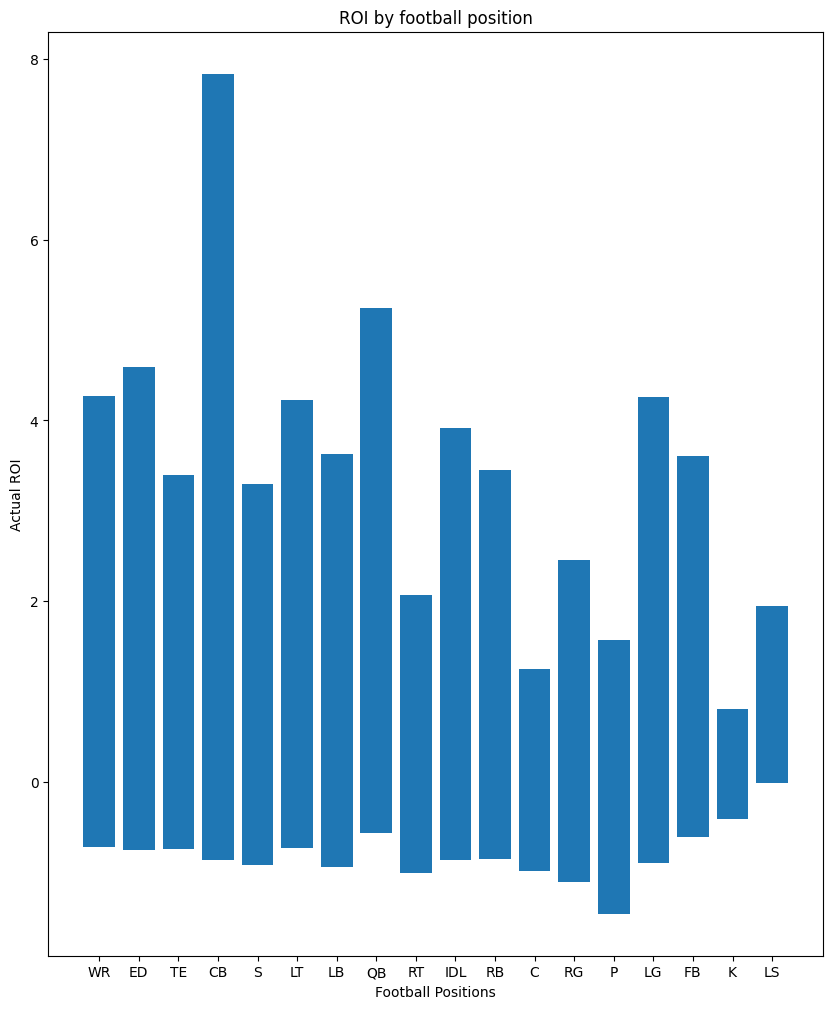

In [63]:
plt.figure(figsize=(10, 12))
plt.bar(x=results['Position'], height=results['Actual_ROI'])
plt.xlabel('Football Positions')
plt.ylabel('Actual ROI')
plt.title('ROI by football position')

(array([  2., 121.,   0., 276.,   0., 274.,  58.,   0.,   7.,   3.]),
 array([20. , 20.6, 21.2, 21.8, 22.4, 23. , 23.6, 24.2, 24.8, 25.4, 26. ]),
 <BarContainer object of 10 artists>)

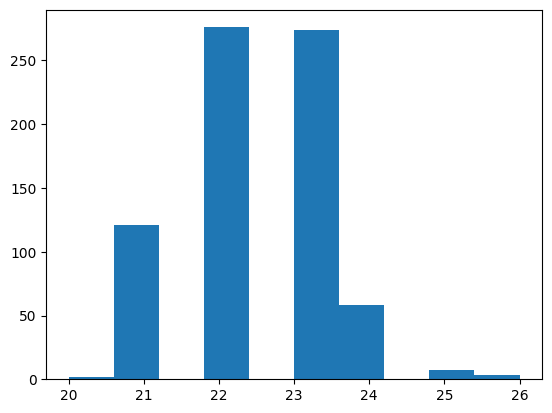

In [64]:
plt.hist(x=results['Age'])

In [66]:
results.sort_values(by='Predicted_ROI')

,Unnamed: 0,Player,Actual_ROI,Predicted_ROI,Pick,Position,BMI_rel,Age,Gem_detected
92,2349,Caleb Wilson,-0.738844,-0.905863,254,TE,-0.802251,23.0,False
310,942,Khalid Wooten,-0.855798,-0.789682,202,CB,2.534150,23.0,True
61,503,Markus White,-0.864838,-0.769839,224,IDL,-2.060222,23.0,True
615,3352,Alex Forsyth,-0.725887,-0.723024,257,C,0.181105,24.0,True
172,3099,Samori Toure,-0.552762,-0.701732,258,WR,-0.652489,24.0,False
...,...,...,...,...,...,...,...,...,...
632,1066,Will Sutton,-0.379184,1.209523,82,IDL,0.750231,22.0,True
6,411,Davon House,0.667115,1.226053,131,CB,-0.046643,22.0,True
117,26,Darren Sproles,3.457643,1.247100,130,RB,0.288014,22.0,False
473,340,Brandon Harris,-0.663834,1.437077,60,CB,0.508934,21.0,True


Text(0.5, 1.0, 'ROI Ratio distribution')

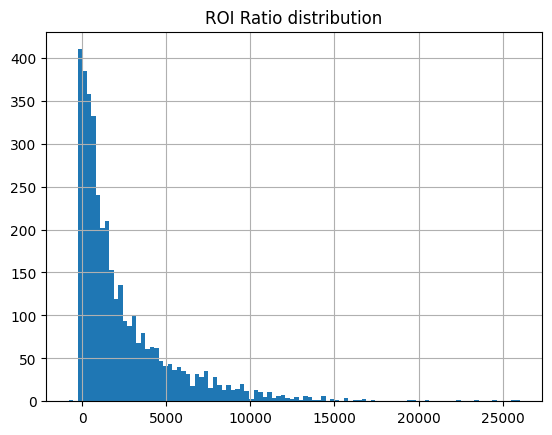

In [76]:
df['bins'] = pd.cut(df['roi_ratio'], bins=100)
df['roi_ratio'].hist(bins=100)
plt.title('ROI Ratio distribution')

In [ ]:
results['Predicted_ROI'].hist(bins=100)
plt.title('Predicted ROI distribution')